### Importación de Librerías
Importamos las librerías fundamentales: **TensorFlow** para el diseño y entrenamiento de la red neuronal, **NumPy** para manipulación matemática y **Matplotlib** para visualizar las imágenes generadas.

In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

### Preparación del Dataset
Cargamos el dataset **MNIST** (dígitos manuscritos). Realizamos dos operaciones clave:
* **Normalización:** Dividimos por 255 para escalar los valores de píxel al rango [0, 1], facilitando el entrenamiento.
* **Split:** Separamos un conjunto de validación, aunque para este ejercicio nos centraremos en el set de entrenamiento `X_train`.

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


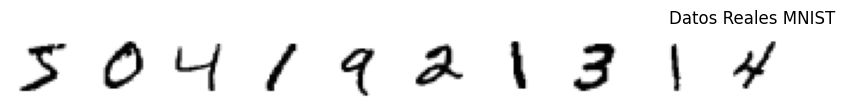

In [2]:
# Cargamos y preprocesamos el dataset MNIST (dígitos)
mnist = tf.keras.datasets.mnist.load_data()
(X_train_full, y_train_full), (X_test, y_test) = mnist

X_train_full = X_train_full.astype(np.float32) / 255
X_train, X_valid = X_train_full[:-5000], X_train_full[-5000:]
y_train, y_valid = y_train_full[:-5000], y_train_full[-5000:]

# Mostramos de los datos reales para verificar
plt.figure(figsize=(10, 5))
for i in range(10):
    plt.subplot(1, 10, i + 1)
    plt.imshow(X_train[i], cmap="binary")
    plt.axis("off")
plt.title("Datos Reales MNIST")
plt.show()

### Función Auxiliar de Visualización
Definimos `plot_multiple_images`, una función herramienta que nos permitirá dibujar una cuadrícula (grid) de imágenes. Esto es esencial para visualizar los "bloques" de dígitos generados y evaluar su calidad visual rápidamente.

In [3]:
def plot_multiple_images(images, n_cols=None):
    n_cols = n_cols or len(images)
    n_rows = (len(images) - 1) // n_cols + 1
    if images.shape[-1] == 1:
        images = images.squeeze(axis=-1)
    plt.figure(figsize=(n_cols, n_rows))
    for index, image in enumerate(images):
        plt.subplot(n_rows, n_cols, index + 1)
        plt.imshow(image, cmap="binary")
        plt.axis("off")

### Lógica de Entrenamiento Personalizada
Esta función contiene el corazón del algoritmo GAN. En cada época (epoch) y para cada lote (batch), realizamos dos fases:
1.  **Fase Discriminador:** Se entrena para distinguir entre imágenes reales (del dataset) y falsas (del generador).
2.  **Fase Generador:** Se entrena el generador (a través del modelo GAN completo) intentando "engañar" al discriminador para que clasifique las imágenes falsas como reales.

*Nota: La función devuelve el último bloque de imágenes generadas para su posterior análisis.*

In [4]:
batch_size = 32
dataset = tf.data.Dataset.from_tensor_slices(X_train).shuffle(1000)
dataset = dataset.batch(batch_size, drop_remainder=True).prefetch(1)

In [5]:
def train_gan(gan, dataset, batch_size, codings_size, n_epochs):
    generator, discriminator = gan.layers
    for epoch in range(n_epochs):
        print(f"Epoch {epoch + 1}/{n_epochs}")  # extra code
        for X_batch in dataset:
            # phase 1 - training the discriminator
            noise = tf.random.normal(shape=[batch_size, codings_size])
            generated_images = generator(noise)
            X_fake_and_real = tf.concat([generated_images, X_batch], axis=0)
            y1 = tf.constant([[0.]] * batch_size + [[1.]] * batch_size)
            discriminator.trainable = True
            discriminator.train_on_batch(X_fake_and_real, y1)
            discriminator.trainable = False
            # phase 2 - training the generator
            noise = tf.random.normal(shape=[batch_size, codings_size])
            y2 = tf.constant([[1.]] * batch_size)
            gan.train_on_batch(noise, y2)
        # extra code — plot images during training
        plot_multiple_images(generated_images.numpy(), 8)
        plt.show()

    return generated_images


### Construcción de la Arquitectura
Aquí definimos la estructura de la red neuronal:
* **Generador:** Toma un vector de ruido (`codings_size`) y lo expande hasta formar una imagen de 28x28.
* **Discriminador:** Toma una imagen de 28x28 y la reduce a una única probabilidad (Real/Falso).

In [6]:
tf.random.set_seed(42)  # extra code – ensures reproducibility on CPU

def build_and_train_gan(codings_size, n_epochs=50):
    print(f"\nIniciando entrenamiento con Codings Size: {codings_size}")

    # Construimos el Generador
    generator = tf.keras.Sequential([
        tf.keras.layers.Input(shape=[codings_size]),
        tf.keras.layers.Dense(100, activation="relu"),
        tf.keras.layers.Dense(150, activation="relu"),
        tf.keras.layers.Dense(28 * 28, activation="sigmoid"),
        tf.keras.layers.Reshape([28, 28])
    ])

    # Construimos el Discriminador
    discriminator = tf.keras.Sequential([
        tf.keras.layers.Input(shape=[28, 28]),
        tf.keras.layers.Flatten(),
        tf.keras.layers.Dense(150, activation="relu"),
        tf.keras.layers.Dense(100, activation="relu"),
        tf.keras.layers.Dense(1, activation="sigmoid")
    ])

    gan = tf.keras.Sequential([generator, discriminator])

    # Compilamos
    discriminator.compile(loss="binary_crossentropy", optimizer="rmsprop")
    discriminator.trainable = False
    gan.compile(loss="binary_crossentropy", optimizer="rmsprop")

    # Dataset
    batch_size = 32
    dataset = tf.data.Dataset.from_tensor_slices(X_train).shuffle(1000)
    dataset = dataset.batch(batch_size, drop_remainder=True).prefetch(1)

    # Entrenamos
    last_block = train_gan(gan, dataset, batch_size, codings_size, n_epochs)

    return last_block

### Ejecución del Experimento (10, 50, 100)
Este es el bucle principal del ejercicio. Iteramos sobre los tres tamaños de vector de entrada solicitados (**10, 50 y 100**).
Para cada tamaño, construimos una nueva GAN desde cero, la entrenamos y guardamos el resultado final en el diccionario `final_blocks` para compararlos al terminar.


Iniciando entrenamiento con Codings Size: 10
Epoch 1/10


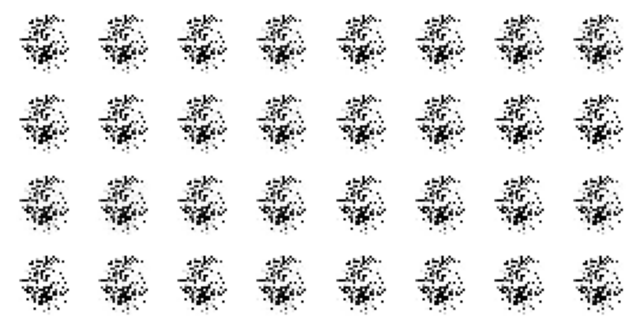

Epoch 2/10


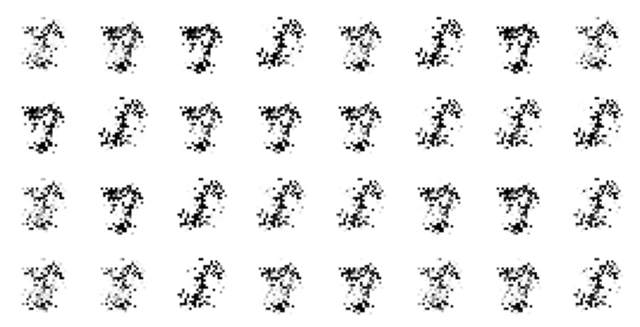

Epoch 3/10


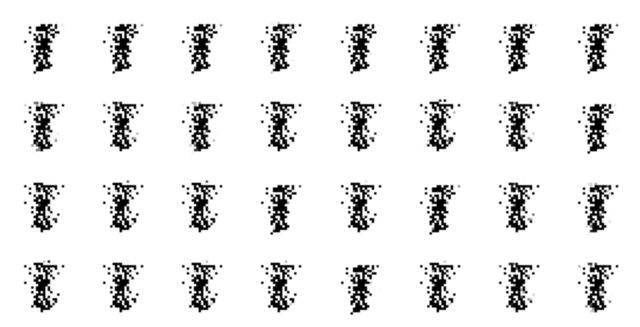

Epoch 4/10


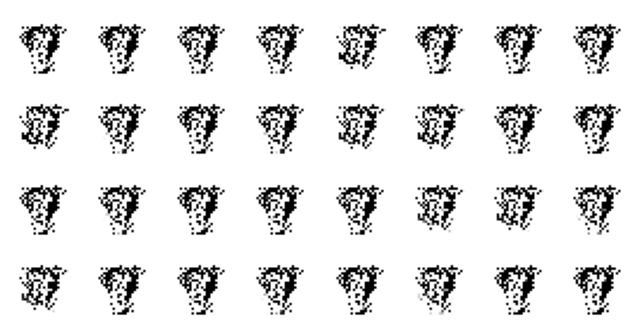

Epoch 5/10


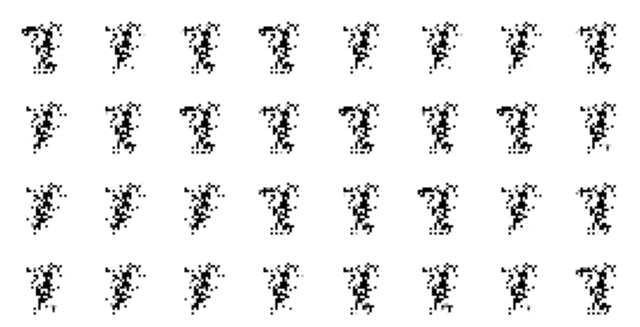

Epoch 6/10


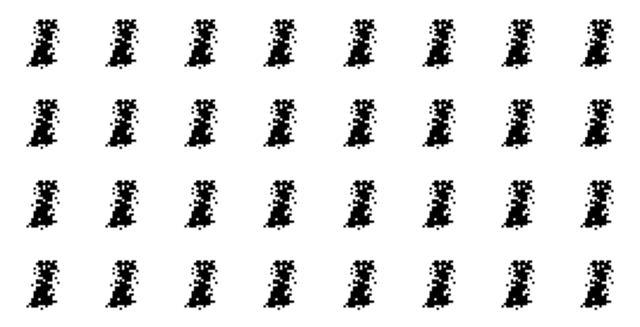

Epoch 7/10


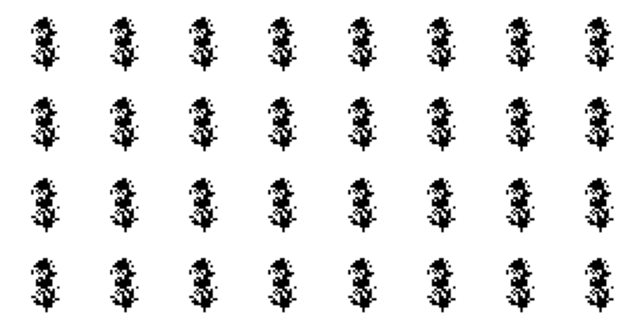

Epoch 8/10


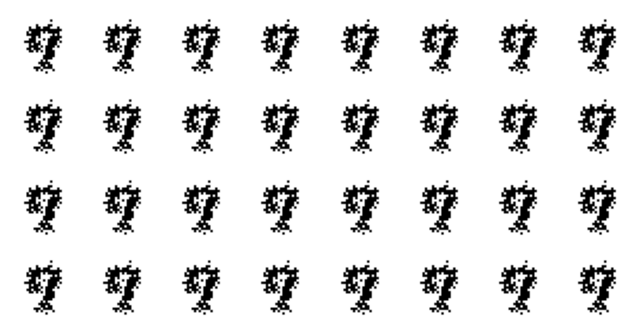

Epoch 9/10


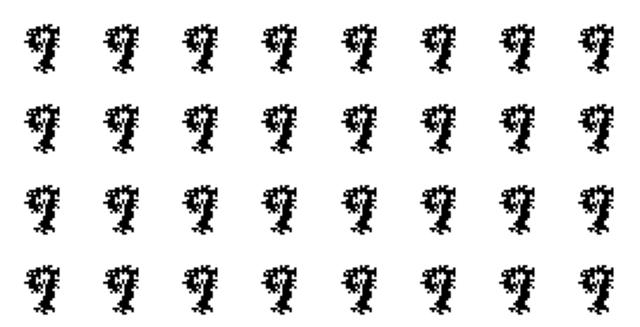

Epoch 10/10


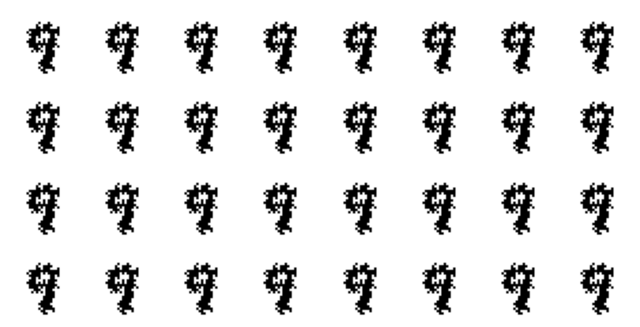


Iniciando entrenamiento con Codings Size: 50
Epoch 1/10


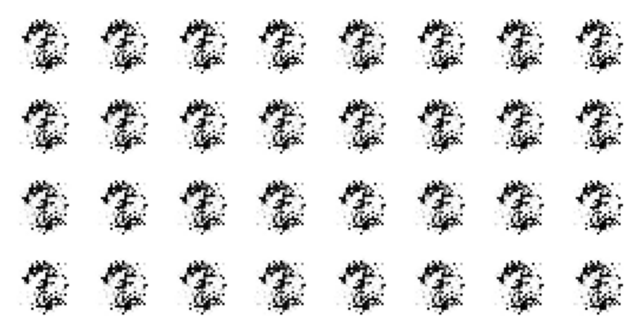

Epoch 2/10


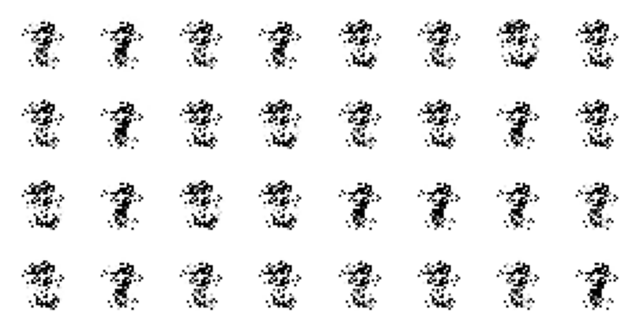

Epoch 3/10


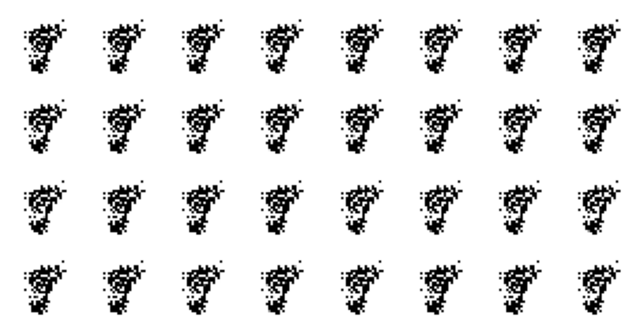

Epoch 4/10


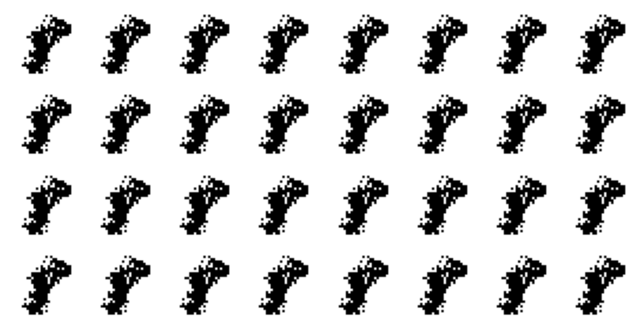

Epoch 5/10


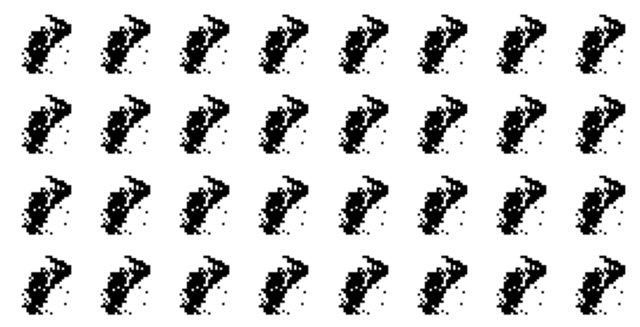

Epoch 6/10


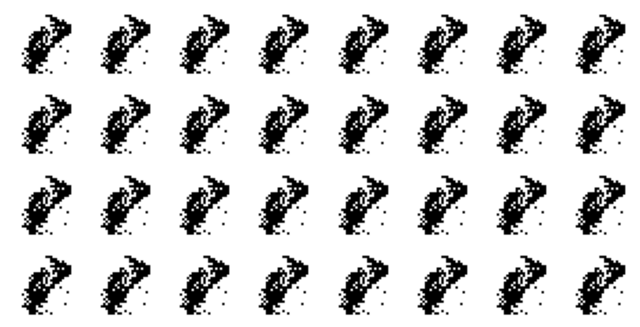

Epoch 7/10


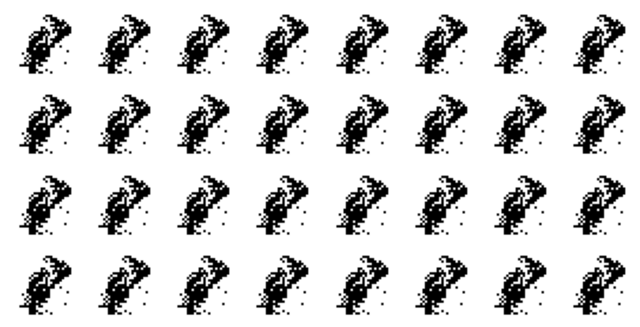

Epoch 8/10


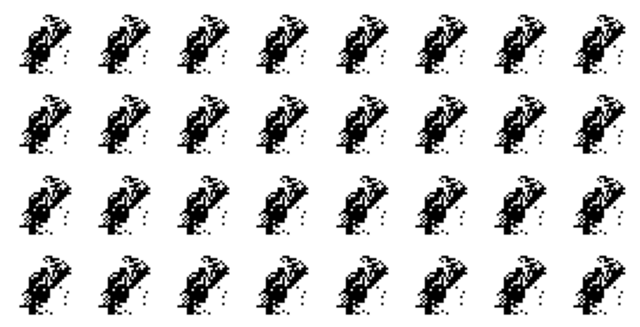

Epoch 9/10


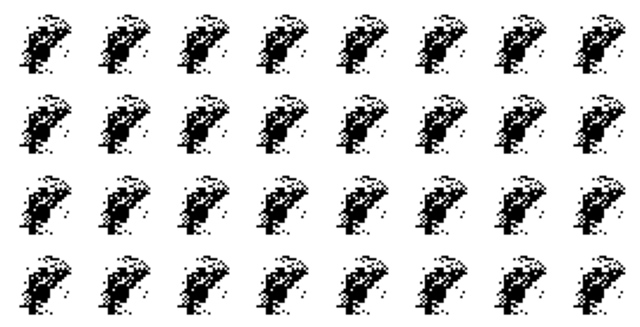

Epoch 10/10


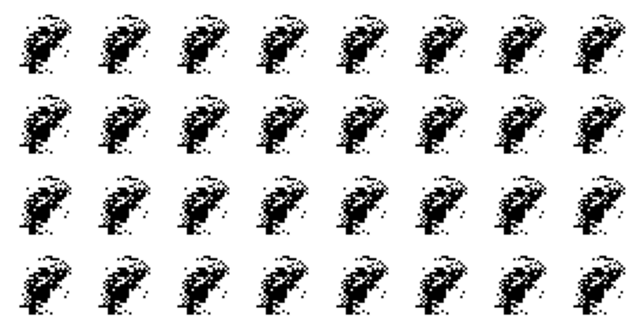


Iniciando entrenamiento con Codings Size: 100
Epoch 1/10


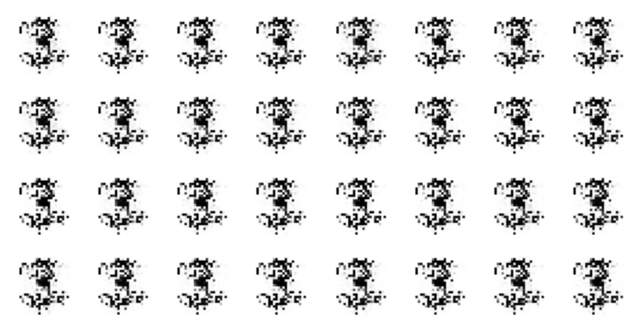

Epoch 2/10


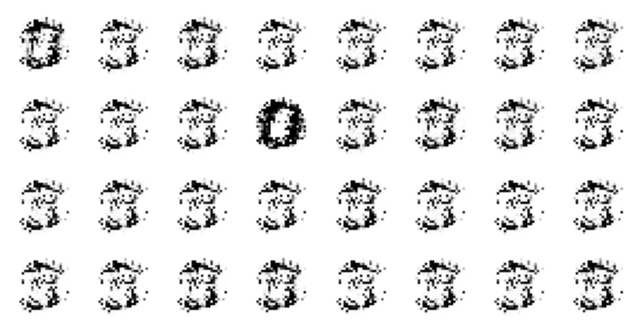

Epoch 3/10


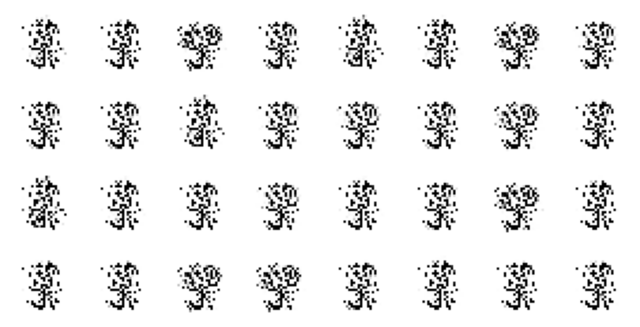

Epoch 4/10


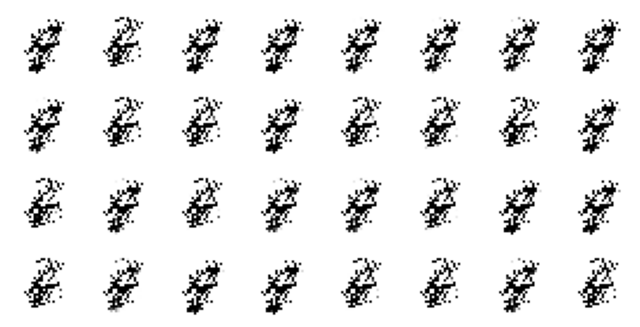

Epoch 5/10


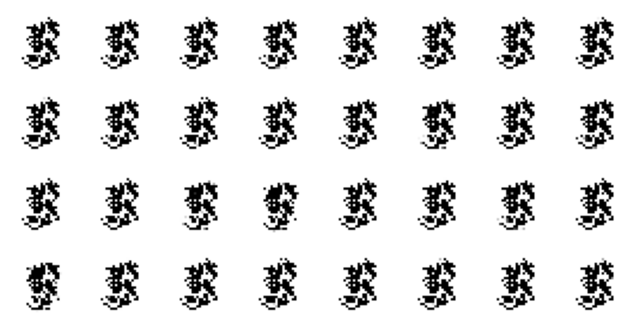

Epoch 6/10


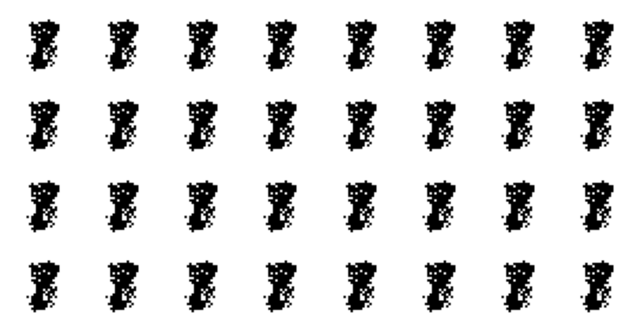

Epoch 7/10


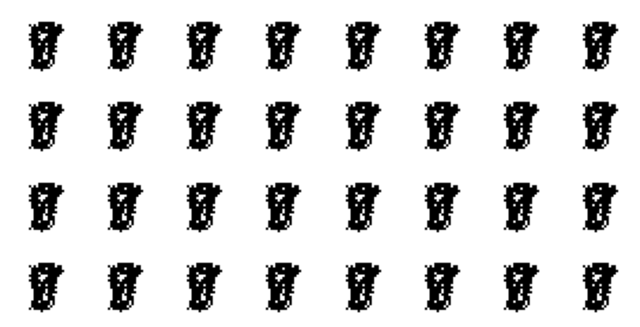

Epoch 8/10


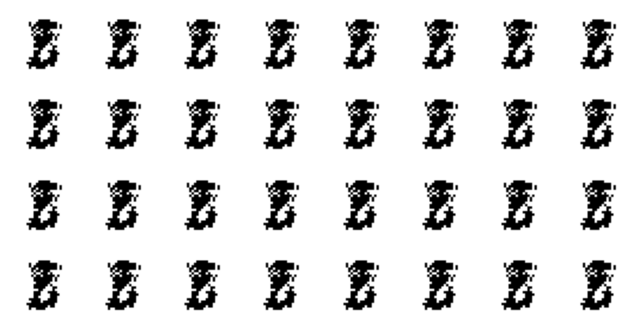

Epoch 9/10


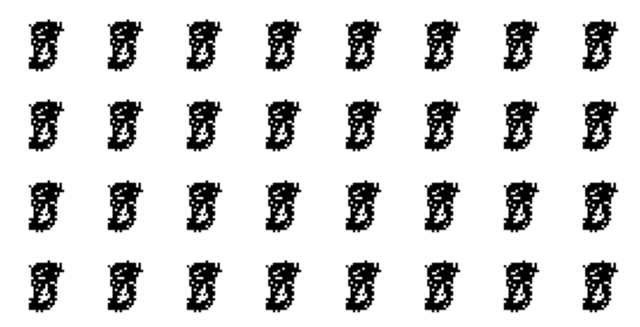

Epoch 10/10


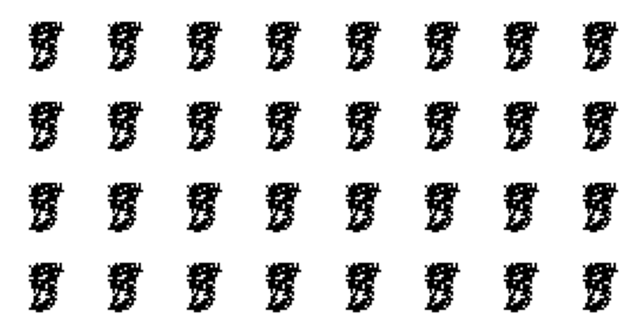

In [7]:
# BUCLE PRINCIPAL
sizes_to_test = [10, 50, 100]
final_blocks = {}

for size in sizes_to_test:
    # Entrenamos y guardamos el generador resultante
    final_blocks[size] = build_and_train_gan(codings_size=size, n_epochs=10)

### Visualización de Resultados
Finalmente, mostramos los últimos bloques de imágenes generados por cada modelo. Esto nos permite comparar directamente cómo afecta el tamaño del vector latente a la calidad y diversidad de los dígitos.


RESULTADOS FINALES

Tamaño del vector de entrada: 10


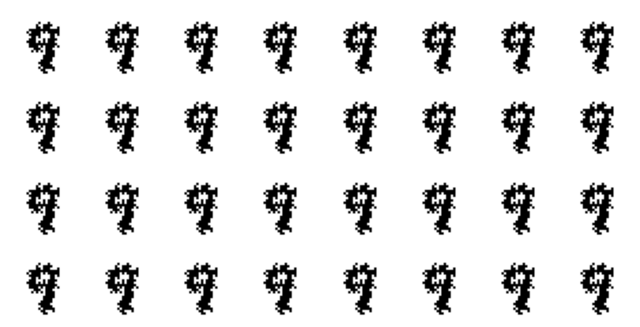


Tamaño del vector de entrada: 50


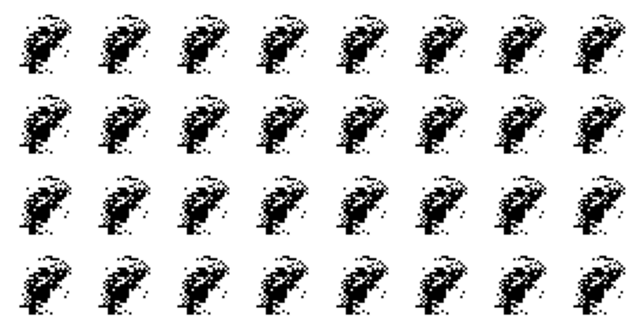


Tamaño del vector de entrada: 100


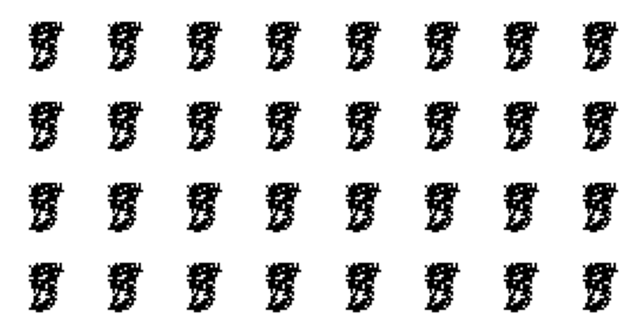

In [8]:
print("\nRESULTADOS FINALES")
for size in sizes_to_test:
    print(f"\nTamaño del vector de entrada: {size}")
    # Mostramos lo que guardamos
    plot_multiple_images(final_blocks[size], n_cols=8)
    plt.show()

### Observaciones y Conclusiones (Resultados Experimentales)
Tras realizar el entrenamiento con diferentes tamaños para el vector de entrada (espacio latente), se observan los siguientes comportamientos:

Tamaño 10 (Mejor Resultado):

Sorprendentemente, este tamaño ha producido las imágenes con mejor calidad visual y definición.

Al tener un espacio latente más compacto, parece que el generador ha logrado converger más rápido a formas fundamentales de los dígitos, evitando generar "ruido" innecesario.

Tamaño 50 y 100 (Peor Calidad):

Al aumentar el tamaño del vector de entrada, la calidad de las imágenes ha disminuido, observándose más ruido o formas menos definidas.

En particular, el tamaño 50 ha mostrado el peor desempeño en esta prueba.

Posible causa: Un espacio latente más grande requiere un entrenamiento más prolongado o delicado para que el generador aprenda a mapear todas las dimensiones correctamente. Al mantener las mismas épocas, es posible que la red con input 50/100 no haya tenido tiempo suficiente para estabilizarse o que el discriminador haya ganado demasiada ventaja ("vanishing gradients").

Conclusión Final: Para esta configuración específica de red y número de épocas, un vector de entrada pequeño (10) resulta mucho más eficiente y estable que vectores más grandes.